<h1 style="color:#E24B4A; font-family:Georgia; text-align:center;">
  <b>🕵️ Fraud Transaction Detection &amp; Risk Intelligence System</b>
</h1>
 
<h2 style="color:#D85A30;"><b>📌 Project Objective</b></h2>
<p>This project builds a complete fraud detection and risk intelligence system using transaction-level and identity-level financial data.</p>
<p>The goal is to:</p>
<ul>
  <li>Analyze fraudulent transaction behavior</li>
  <li>Identify suspicious transaction patterns</li>
  <li>Engineer fraud-related features</li>
  <li>Handle class imbalance</li>
  <li>Build machine learning models</li>
  <li>Apply anomaly detection</li>
  <li>Generate fraud probability and risk segments</li>
</ul>
 
<h2 style="color:#D85A30;"><b>📂 Dataset Files</b></h2>
<p>The project uses five files:</p>
<ul>
  <li><code>train_transaction.csv</code></li>
  <li><code>train_identity.csv</code></li>
</ul>
<p>Training files contain the fraud label <code>isFraud</code>. Test files are used for final fraud probability prediction.</p>
 
</body>
</html>

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

import warnings
warnings.filterwarnings("ignore")

<h1 style="color:#D85A30 ; font-family:Georgia"> <b>
Load Dataset</b>
</h1>

In [131]:
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

In [132]:
print("Train Transaction Shape:", train_transaction.shape)
print("Train Identity Shape:", train_identity.shape)

Train Transaction Shape: (590540, 394)
Train Identity Shape: (144233, 41)


In [133]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [134]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [135]:
train_identity.columns = train_identity.columns.str.replace("-", "_")
print(train_identity.columns[:10])

Index(['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
       'id_07', 'id_08', 'id_09'],
      dtype='str')


<h1 style="color:#D85A30 ; font-family:Georgia"> <b>
Merge Transaction and Identity Data</b>
</h1>

In [136]:
train_df = train_transaction.merge(train_identity,on="TransactionID",how="left")
print("Merged Train Shape:", train_df.shape)

Merged Train Shape: (590540, 434)


In [137]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [138]:
train_df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.00,6.000000e+02
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.00,2.310000e+02
card5,586281.0,1.992789e+02,4.124445e+01,100.000,166.000,226.000,226.00,2.370000e+02
addr1,524834.0,2.907338e+02,1.017411e+02,100.000,204.000,299.000,330.00,5.400000e+02
addr2,524834.0,8.680063e+01,2.690623e+00,10.000,87.000,87.000,87.00,1.020000e+02


In [139]:
print("Duplicate Rows:", train_df.duplicated().sum())
print("Duplicate TransactionID:", train_df["TransactionID"].duplicated().sum())

Duplicate Rows: 0
Duplicate TransactionID: 0


In [140]:
missing_df = pd.DataFrame({"Missing_Count": train_df.isnull().sum(),
    "Missing_Percentage": train_df.isnull().mean() * 100
}).sort_values(by="Missing_Percentage", ascending=False)
missing_df.head(30)

,Missing_Count,Missing_Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


<h1 style="color:#D85A30 ; font-family:Georgia"> <b>
Target Variable Analysis</b>
</h1>

## Fraud Distribution

The target variable is `isFraud`.

- 0 = Normal transaction
- 1 = Fraudulent transaction

Fraud datasets are usually highly imbalanced.

In [141]:
fraud_count = train_df["isFraud"].value_counts()
fraud_percent = (train_df["isFraud"].value_counts(normalize=True) * 100).round(2)

print(fraud_count)
print(fraud_percent.astype(str) + "%")

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    96.5%
1     3.5%
Name: proportion, dtype: str


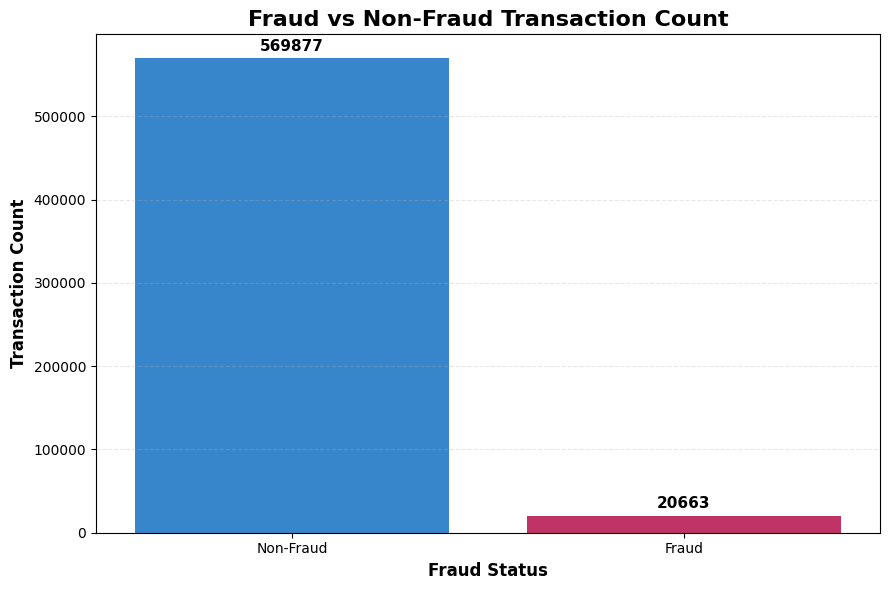

In [144]:
plt.figure(figsize=(9,6))

ax = sns.countplot(data=train_df, x="isFraud",palette=["#1E88E5", "#D81B60"])

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

plt.title("Fraud vs Non-Fraud Transaction Count",fontsize=16,fontweight="bold")

plt.xlabel("Fraud Status",fontsize=12,fontweight="bold")

plt.ylabel("Transaction Count",fontsize=12,fontweight="bold")

plt.xticks([0,1],["Non-Fraud", "Fraud"])

plt.grid(axis="y", linestyle="--",alpha=0.3)

plt.tight_layout()

plt.show()

In [145]:
fraud_rate = train_df["isFraud"].mean() * 100
print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 3.50%


In [146]:
# Transaction Amount Analysis

train_df["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

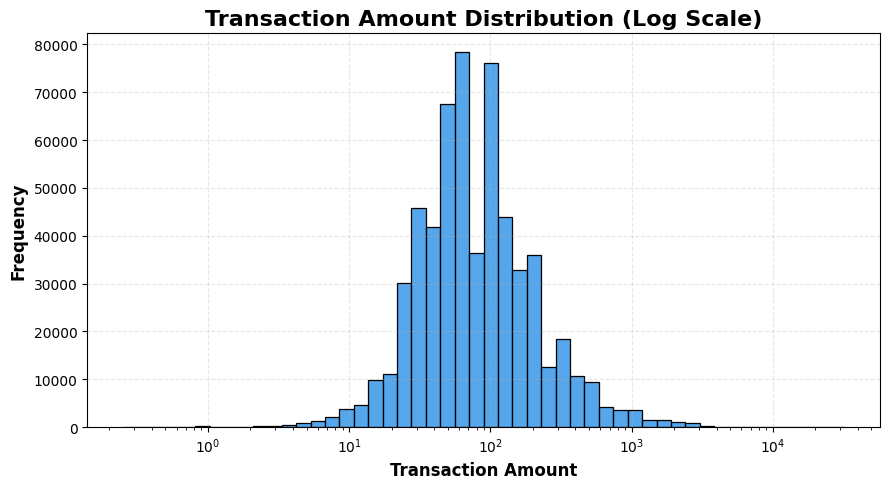

In [147]:
plt.figure(figsize=(9,5))

sns.histplot(train_df["TransactionAmt"],bins=50,color="#1E88E5",edgecolor="black",log_scale=True)

plt.title("Transaction Amount Distribution (Log Scale)",fontsize=16,fontweight="bold")

plt.xlabel("Transaction Amount",fontsize=12,fontweight="bold")

plt.ylabel("Frequency",fontsize=12,fontweight="bold")

plt.grid(linestyle="--",alpha=0.3)

plt.tight_layout()

plt.show()

<p><i>Most transactions are concentrated in the lower amount range, mainly between small to medium transaction values. The distribution is highly right-skewed because a few transactions have extremely large amounts compared to the majority. The log scale helps visualize the data more clearly by reducing the impact of outliers.</i></p>

In [148]:
train_df["TransactionAmt_log"] = np.log1p(train_df["TransactionAmt"])

In [149]:
test_df["TransactionAmt_log"] = np.log1p(test_df["TransactionAmt"])

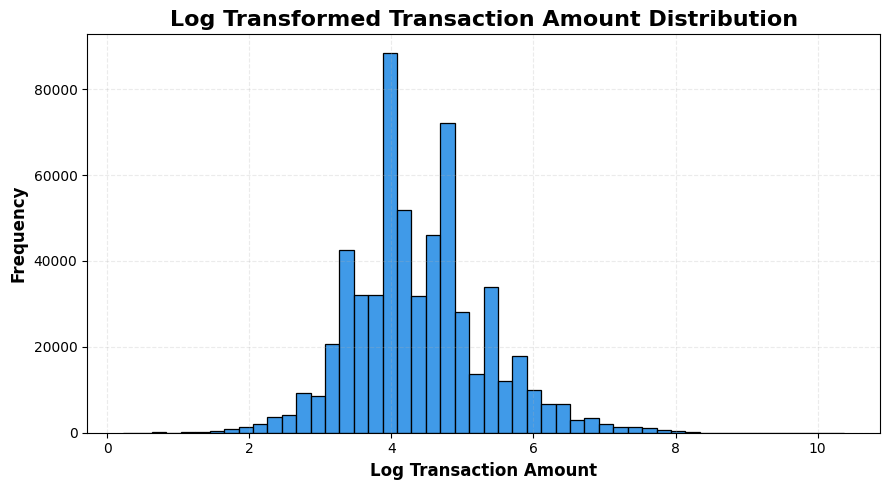

In [150]:
plt.figure(figsize=(9,5))

sns.histplot(train_df["TransactionAmt_log"],bins=50,color="#1E88E5",edgecolor="black",alpha=0.85)

plt.title("Log Transformed Transaction Amount Distribution",fontsize=16,fontweight="bold")

plt.xlabel("Log Transaction Amount",fontsize=12,fontweight="bold")

plt.ylabel("Frequency",fontsize=12,fontweight="bold")

plt.grid(linestyle="--",alpha=0.25)

plt.tight_layout()

plt.show()

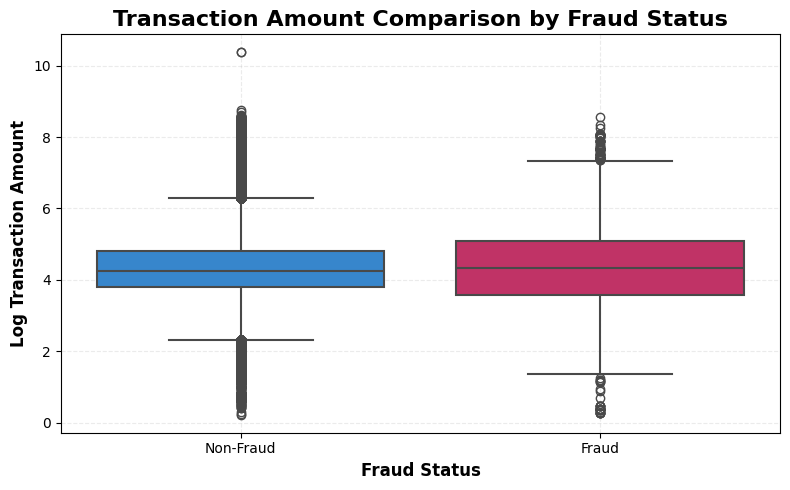

In [151]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train_df,x="isFraud",y="TransactionAmt_log",palette=["#1E88E5", "#D81B60"],linewidth=1.5)

plt.title("Transaction Amount Comparison by Fraud Status",fontsize=16,fontweight="bold")

plt.xlabel("Fraud Status",fontsize=12,fontweight="bold")

plt.ylabel("Log Transaction Amount",fontsize=12,fontweight="bold")

plt.xticks([0,1],["Non-Fraud", "Fraud"])

plt.grid(linestyle="--",alpha=0.25)

plt.tight_layout()

plt.show()

<p><i>The boxplot compares the distribution of transaction amounts between fraud and non-fraud transactions after applying log transformation. Fraud transactions show slightly higher median values and a wider spread compared to non-fraud transactions. Multiple outliers are still present because financial transaction data naturally contains some extremely high-value transactions.</p></i>

In [153]:
# Amount Feature

train_df["amount_decimal"] = train_df["TransactionAmt"] - train_df["TransactionAmt"].astype(int)
amount_95 = train_df["TransactionAmt"].quantile(0.95)
train_df["high_amount_flag"] = (train_df["TransactionAmt"] > amount_95).astype(int)

In [154]:
train_df[["TransactionAmt","amount_decimal","high_amount_flag"]].head(10)

,TransactionAmt,amount_decimal,high_amount_flag
0,68.5,0.5,0
1,29.0,0.0,0
2,59.0,0.0,0
3,50.0,0.0,0
4,50.0,0.0,0
5,49.0,0.0,0
6,159.0,0.0,0
7,422.5,0.5,0
8,15.0,0.0,0
9,117.0,0.0,0


In [155]:
train_df["amount_bucket"] = pd.qcut(train_df["TransactionAmt"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

amount_bucket_fraud = (train_df.groupby("amount_bucket")["isFraud"].mean() * 100).round(2)
print(amount_bucket_fraud.astype(str) + "%")

amount_bucket
Very Low     4.38%
Low          2.61%
Medium       3.31%
High          2.7%
Very High    4.45%
Name: isFraud, dtype: str


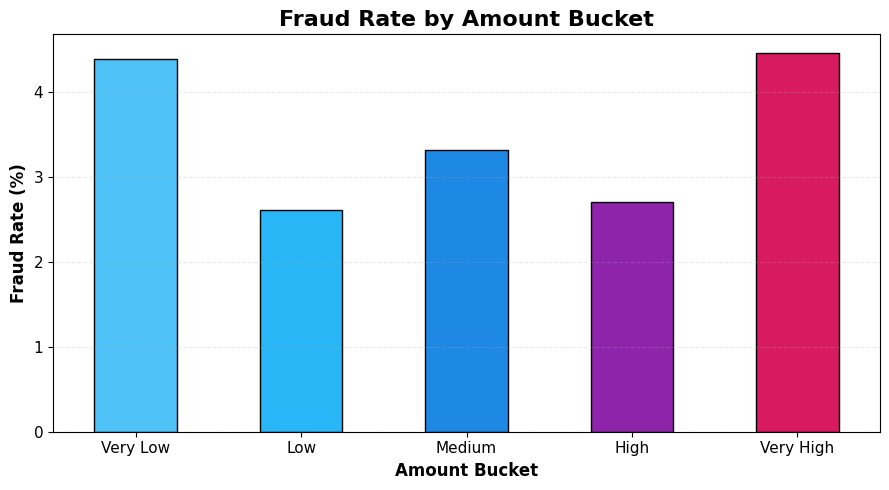

In [156]:
plt.figure(figsize=(9,5))

amount_bucket_fraud.plot(kind="bar",color=["#4FC3F7", "#29B6F6", "#1E88E5", "#8E24AA", "#D81B60"],edgecolor="black")

plt.title("Fraud Rate by Amount Bucket",fontsize=16,fontweight="bold")

plt.xlabel("Amount Bucket",fontsize=12,fontweight="bold")

plt.ylabel("Fraud Rate (%)",fontsize=12,fontweight="bold")

plt.xticks(rotation=0,fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y",linestyle="--",alpha=0.25)

plt.tight_layout()

plt.show()

In [157]:
# Time-Based Feature

train_df["Transaction_Day"] = train_df["TransactionDT"] // (24 * 60 * 60)

train_df["Transaction_Hour"] = (train_df["TransactionDT"] // (60 * 60)) % 24

train_df["Transaction_Week"] = train_df["Transaction_Day"] // 7

train_df["is_night_transaction"] = train_df["Transaction_Hour"].isin([0,1,2,3,4,5]).astype(int)

In [158]:
train_df[["TransactionDT", "Transaction_Day","Transaction_Hour","Transaction_Week","is_night_transaction"]].head(10)

,TransactionDT,Transaction_Day,Transaction_Hour,Transaction_Week,is_night_transaction
0,86400,1,0,0,1
1,86401,1,0,0,1
2,86469,1,0,0,1
3,86499,1,0,0,1
4,86506,1,0,0,1
5,86510,1,0,0,1
6,86522,1,0,0,1
7,86529,1,0,0,1
8,86535,1,0,0,1
9,86536,1,0,0,1


In [159]:
hourly_fraud = train_df.groupby("Transaction_Hour")["isFraud"].mean() * 100
hourly_fraud

Transaction_Hour
0      3.137981
1      3.131384
2      3.748317
3      3.831362
4      5.189029
5      7.030203
6      7.774263
7     10.610151
8      9.301428
9      8.995563
10     5.321202
11     3.881646
12     3.043932
13     2.288949
14     2.421632
15     2.539945
16     2.951057
17     3.153009
18     3.523139
19     3.473822
20     3.427313
21     3.400495
22     3.269404
23     3.699717
Name: isFraud, dtype: float64

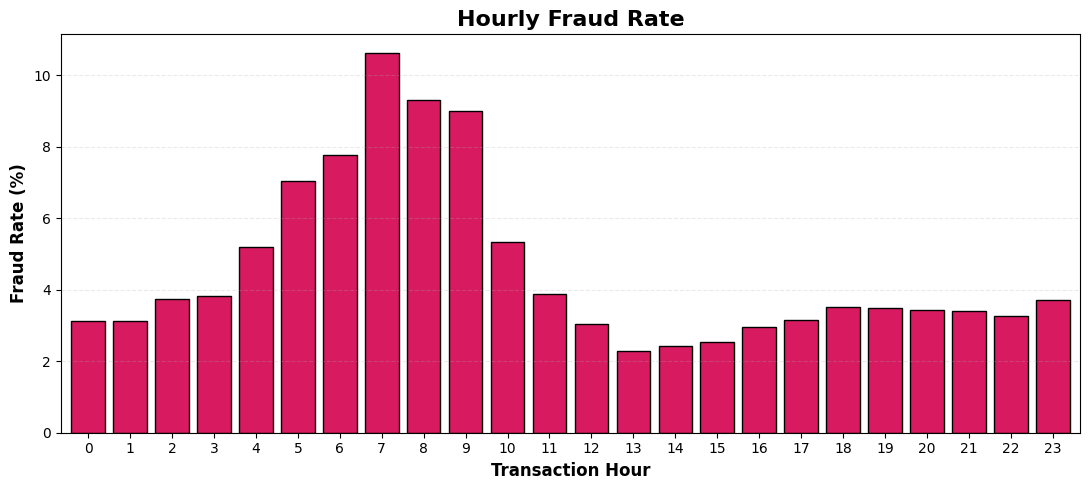

In [160]:
plt.figure(figsize=(11,5))

hourly_fraud.plot(kind="bar",color="#D81B60",edgecolor="black",width=0.8)

plt.title("Hourly Fraud Rate",fontsize=16,fontweight="bold")

plt.xlabel("Transaction Hour",fontsize=12,fontweight="bold")

plt.ylabel("Fraud Rate (%)",fontsize=12,fontweight="bold")

plt.xticks(rotation=0,fontsize=10)

plt.yticks(fontsize=10)

plt.grid(axis="y",linestyle="--",alpha=0.25)

plt.tight_layout()

plt.show()

In [161]:
daily_fraud = train_df.groupby("Transaction_Day")["isFraud"].sum()
daily_fraud

Transaction_Day
1      112
2      123
3       92
4      115
5      127
      ... 
178     88
179     66
180     98
181    122
182    119
Name: isFraud, Length: 182, dtype: int64

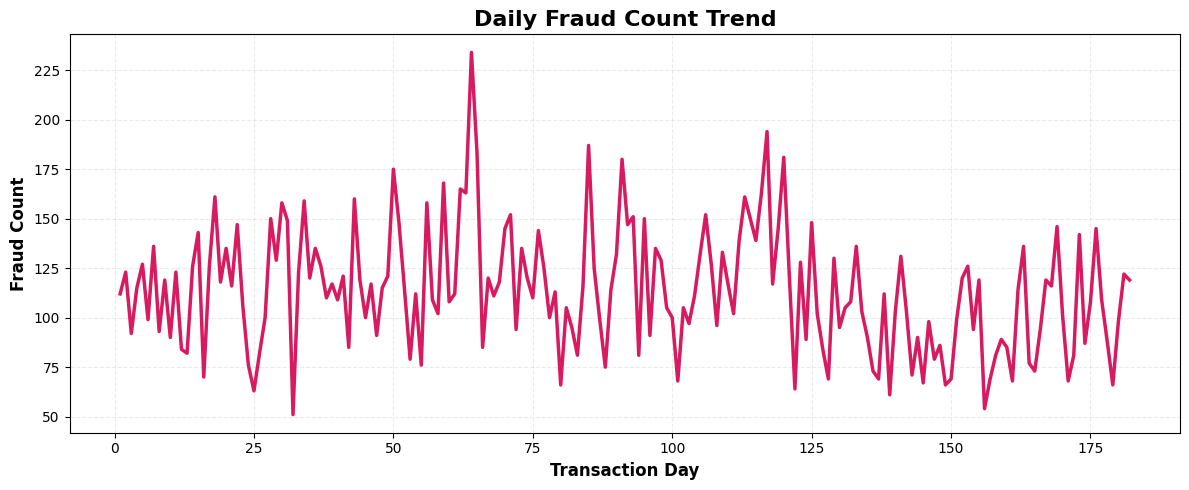

In [162]:
plt.figure(figsize=(12,5))

daily_fraud.plot(color="#D81B60",linewidth=2.5)

plt.title("Daily Fraud Count Trend",fontsize=16,fontweight="bold")

plt.xlabel("Transaction Day",fontsize=12,fontweight="bold")

plt.ylabel("Fraud Count",fontsize=12,fontweight="bold")

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(linestyle="--",alpha=0.25)

plt.tight_layout()

plt.show()

In [163]:
# Product Analysis

product_summary = train_df.groupby("ProductCD").agg(
    Transaction_Count=("TransactionID", "count"),Fraud_Count=("isFraud", "sum"),Fraud_Rate=("isFraud", "mean")
).sort_values(by="Fraud_Rate", ascending=False)

product_summary["Fraud_Rate"] = product_summary["Fraud_Rate"] * 100
product_summary

,Transaction_Count,Fraud_Count,Fraud_Rate
ProductCD,,,
C,68519,8008,11.687269
S,11628,686,5.899553
H,33024,1574,4.766231
R,37699,1426,3.782594
W,439670,8969,2.039939


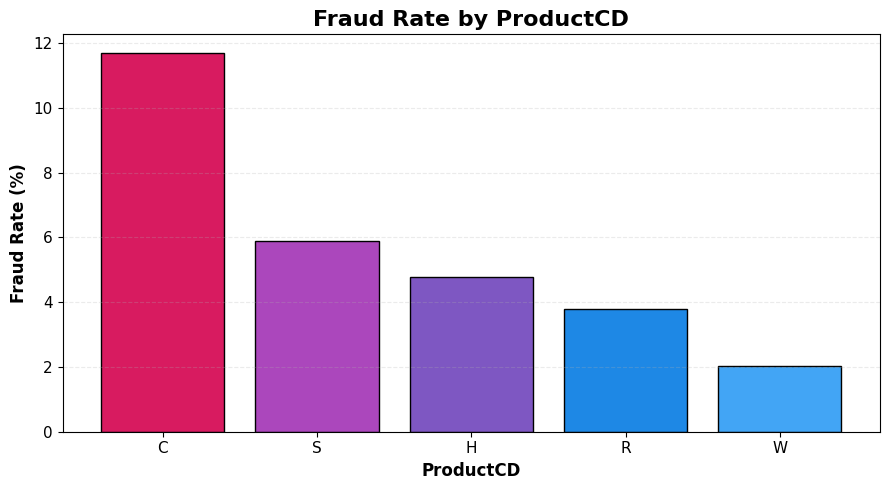

In [164]:
plt.figure(figsize=(9,5))

product_summary["Fraud_Rate"].plot(kind="bar",color=["#D81B60","#AB47BC","#7E57C2","#1E88E5", "#42A5F5"],
    edgecolor="black",width=0.8)

plt.title("Fraud Rate by ProductCD",fontsize=16,fontweight="bold")

plt.xlabel("ProductCD",fontsize=12,fontweight="bold")

plt.ylabel("Fraud Rate (%)",fontsize=12,fontweight="bold")

plt.xticks(rotation=0,fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y",linestyle="--",alpha=0.25)

plt.tight_layout()

plt.show()

In [165]:
# Card Feature Analysis

card4_fraud = train_df.groupby("card4")["isFraud"].mean().sort_values(ascending=False) * 100
card6_fraud = train_df.groupby("card6")["isFraud"].mean().sort_values(ascending=False) * 100

In [166]:
card4_fraud

card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64

In [167]:
card6_fraud

card6
credit             6.678480
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

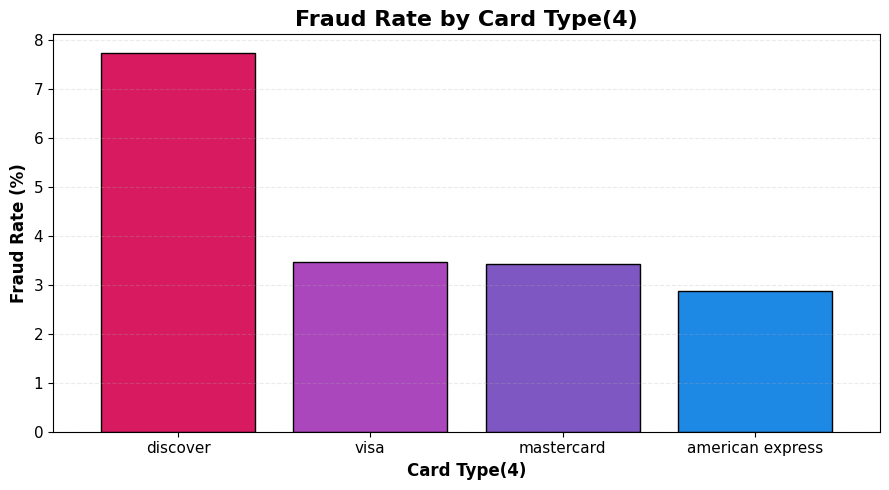

In [168]:
plt.figure(figsize=(9,5))

card4_fraud.plot(kind="bar",color=["#D81B60","#AB47BC","#7E57C2","#1E88E5", "#42A5F5"],edgecolor="black",width=0.8)

plt.title("Fraud Rate by Card Type(4)",fontsize=16,fontweight="bold")

plt.xlabel("Card Type(4)",fontsize=12,fontweight="bold")

plt.ylabel("Fraud Rate (%)",fontsize=12,fontweight="bold")

plt.xticks(rotation=0,fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y",linestyle="--",alpha=0.25)

plt.tight_layout()

plt.show()

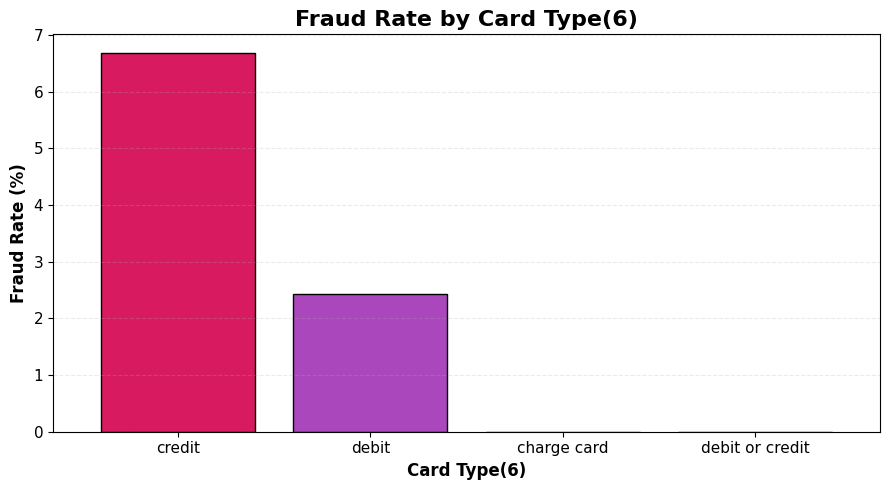

In [169]:
plt.figure(figsize=(9,5))

card6_fraud.plot(kind="bar", color=["#D81B60","#AB47BC","#7E57C2","#1E88E5","#42A5F5"], edgecolor="black", width=0.8)

plt.title("Fraud Rate by Card Type(6)", fontsize=16, fontweight="bold")

plt.xlabel("Card Type(6)", fontsize=12, fontweight="bold")

plt.ylabel("Fraud Rate (%)", fontsize=12, fontweight="bold")

plt.xticks(rotation=0, fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()

plt.show()

In [171]:
# Card Frequency Features

for col in ["card1", "card2", "card3", "card5"]:
    freq_map = train_df[col].value_counts()
    train_df[f"{col}_freq"] = train_df[col].map(freq_map)

In [172]:
train_df["card_combo"] = (
    train_df["card1"].astype(str) + "_" +
    train_df["card4"].astype(str) + "_" +
    train_df["card6"].astype(str)
)
card_combo_freq = train_df["card_combo"].value_counts()

In [173]:
train_df["card_combo_freq"] = train_df["card_combo"].map(card_combo_freq)


In [174]:
train_df[
    [
        "card1",
        "card4",
        "card6",
        "card_combo"
    ]
].head(10)

,card1,card4,card6,card_combo
0,13926,discover,credit,13926_discover_credit
1,2755,mastercard,credit,2755_mastercard_credit
2,4663,visa,debit,4663_visa_debit
3,18132,mastercard,debit,18132_mastercard_debit
4,4497,mastercard,credit,4497_mastercard_credit
5,5937,visa,debit,5937_visa_debit
6,12308,visa,debit,12308_visa_debit
7,12695,visa,debit,12695_visa_debit
8,2803,visa,debit,2803_visa_debit
9,17399,mastercard,debit,17399_mastercard_debit


In [175]:
train_df[["card_combo","card_combo_freq"]].head(10)

,card_combo,card_combo_freq
0,13926_discover_credit,43.0
1,2755_mastercard_credit,678.0
2,4663_visa_debit,1104.0
3,18132_mastercard_debit,4197.0
4,4497_mastercard_credit,18.0
5,5937_visa_debit,7.0
6,12308_visa_debit,206.0
7,12695_visa_debit,7079.0
8,2803_visa_debit,6126.0
9,17399_mastercard_debit,1912.0


In [176]:
train_df["card_combo"].value_counts().head(10)

card_combo
7919_mastercard_debit      14891
9500_visa_debit            14112
15885_visa_debit           10332
17188_visa_debit           10312
15066_mastercard_credit     7918
12695_visa_debit            7079
6019_visa_credit            6766
12544_visa_debit            6760
2803_visa_debit             6126
7585_visa_credit            5325
Name: count, dtype: int64

In [177]:
train_df[
    [
        "card1",
        "card1_freq",
        "card2",
        "card2_freq",
        "card3",
        "card3_freq",
        "card5",
        "card5_freq"
    ]
].head(10)

,card1,card1_freq,card2,card2_freq,card3,card3_freq,card5,card5_freq
0,13926,43,NaN,NaN,150.0,521287.0,142.0,277.0
1,2755,683,404.0,3056.0,150.0,521287.0,102.0,29105.0
2,4663,1108,490.0,38145.0,150.0,521287.0,166.0,57140.0
3,18132,4209,567.0,6137.0,150.0,521287.0,117.0,25941.0
4,4497,18,514.0,14541.0,150.0,521287.0,102.0,29105.0
5,5937,7,555.0,41995.0,150.0,521287.0,226.0,296546.0
6,12308,207,360.0,15190.0,150.0,521287.0,166.0,57140.0
7,12695,7091,490.0,38145.0,150.0,521287.0,226.0,296546.0
8,2803,6141,100.0,7570.0,150.0,521287.0,226.0,296546.0
9,17399,1916,111.0,45191.0,150.0,521287.0,224.0,81513.0


In [178]:
# Email  Analysis

p_email_fraud = train_df.groupby("P_emaildomain")["isFraud"].mean().sort_values(ascending=False) * 100
r_email_fraud = train_df.groupby("R_emaildomain")["isFraud"].mean().sort_values(ascending=False) * 100

In [179]:
p_email_fraud.head(15)

P_emaildomain
protonmail.com    40.789474
mail.com          18.962433
outlook.es        13.013699
aim.com           12.698413
outlook.com        9.458399
hotmail.es         6.557377
live.com.mx        5.473965
hotmail.com        5.295028
gmail.com          4.354185
yahoo.fr           3.496503
embarqmail.com     3.461538
mac.com            3.211009
icloud.com         3.143450
comcast.net        3.118661
charter.net        3.063725
Name: isFraud, dtype: float64

In [180]:
r_email_fraud.head(15)

R_emaildomain
protonmail.com    95.121951
mail.com          37.704918
netzero.net       22.222222
outlook.com       16.513761
outlook.es        13.163972
icloud.com        12.875536
gmail.com         11.918386
hotmail.com        7.779272
earthlink.net      7.594937
hotmail.es         6.849315
live.com.mx        5.835544
yahoo.com          5.151157
live.com           4.986877
rocketmail.com     4.347826
suddenlink.net     4.000000
Name: isFraud, dtype: float64

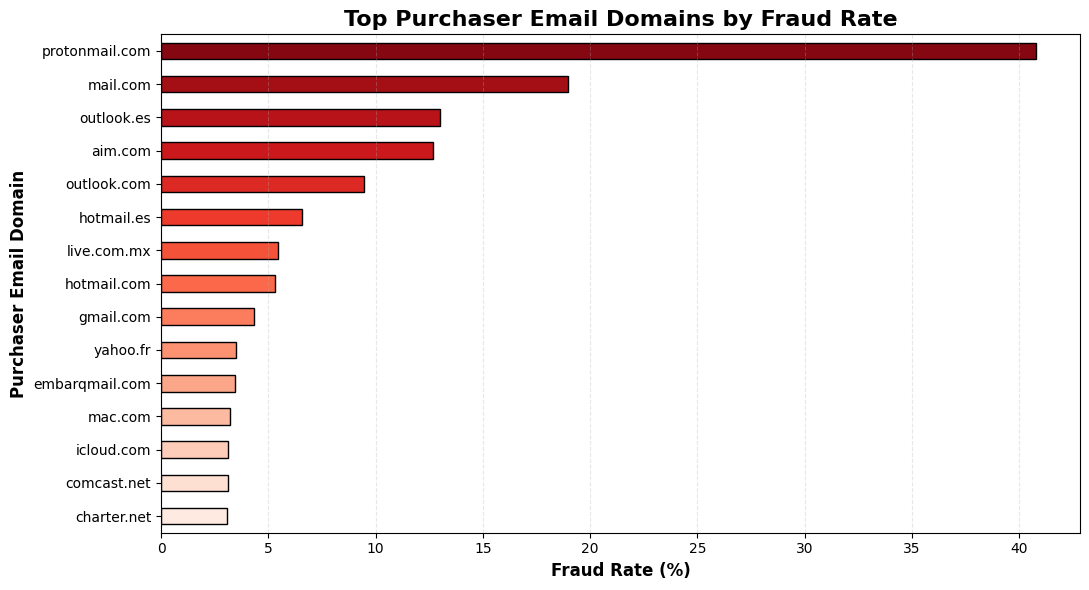

In [181]:
plt.figure(figsize=(11,6))

p_email_fraud.head(15).sort_values().plot(kind="barh", color=sns.color_palette("Reds", 15), edgecolor="black")

plt.title("Top Purchaser Email Domains by Fraud Rate", fontsize=16, fontweight="bold")

plt.xlabel("Fraud Rate (%)", fontsize=12, fontweight="bold")

plt.ylabel("Purchaser Email Domain", fontsize=12, fontweight="bold")

plt.xticks(fontsize=10)

plt.yticks(fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [182]:
train_df["email_domain_match"] = (train_df["P_emaildomain"] == train_df["R_emaildomain"]).astype(int)

test_df["email_domain_match"] = (test_df["P_emaildomain"] == test_df["R_emaildomain"]).astype(int)

In [183]:
email_match_fraud = train_df.groupby("email_domain_match")["isFraud"].mean() * 100
email_match_fraud

email_domain_match
0    2.207009
1    9.650355
Name: isFraud, dtype: float64

In [185]:
# Email Frequency Features

for col in ["P_emaildomain", "R_emaildomain"]:
    freq_map = train_df[col].value_counts()
    train_df[f"{col}_freq"] = train_df[col].map(freq_map)

In [186]:
train_df[
    [
        "P_emaildomain",
        "P_emaildomain_freq",
        "R_emaildomain",
        "R_emaildomain_freq"
    ]
].head(10)

,P_emaildomain,P_emaildomain_freq,R_emaildomain,R_emaildomain_freq
0,NaN,NaN,NaN,NaN
1,gmail.com,228355.0,NaN,NaN
2,outlook.com,5096.0,NaN,NaN
3,yahoo.com,100934.0,NaN,NaN
4,gmail.com,228355.0,NaN,NaN
5,gmail.com,228355.0,NaN,NaN
6,yahoo.com,100934.0,NaN,NaN
7,mail.com,559.0,NaN,NaN
8,anonymous.com,36998.0,NaN,NaN
9,yahoo.com,100934.0,NaN,NaN


In [187]:
# Address and Distance Analysis

addr1_fraud = train_df.groupby("addr1")["isFraud"].mean().sort_values(ascending=False) * 100
addr1_fraud.head(10)

addr1
305.0    66.666667
483.0    56.521739
466.0    50.000000
501.0    50.000000
471.0    50.000000
391.0    45.714286
431.0    34.210526
260.0    33.333333
432.0    28.947368
216.0    24.074074
Name: isFraud, dtype: float64

In [188]:
for col in ["addr1", "addr2"]:
    freq_map = train_df[col].value_counts()
    train_df[f"{col}_freq"] = train_df[col].map(freq_map)

In [189]:
train_df["dist1_missing_flag"] = train_df["dist1"].isnull().astype(int)
train_df["dist2_missing_flag"] = train_df["dist2"].isnull().astype(int)

In [190]:
train_df[
    [
        "dist1",
        "dist1_missing_flag",
        "dist2",
        "dist2_missing_flag"
    ]
].head(10)

,dist1,dist1_missing_flag,dist2,dist2_missing_flag
0,19.0,0,NaN,1
1,NaN,1,NaN,1
2,287.0,0,NaN,1
3,NaN,1,NaN,1
4,NaN,1,NaN,1
5,36.0,0,NaN,1
6,0.0,0,NaN,1
7,NaN,1,NaN,1
8,NaN,1,NaN,1
9,19.0,0,NaN,1


In [191]:
train_df["dist1_missing_flag"].value_counts()

dist1_missing_flag
1    352271
0    238269
Name: count, dtype: int64

In [192]:
train_df.groupby("dist1_missing_flag")["isFraud"].mean() * 100

dist1_missing_flag
0    1.995644
1    4.515841
Name: isFraud, dtype: float64

In [193]:
# Device Analysis

device_fraud = train_df.groupby("DeviceType")["isFraud"].mean().sort_values(ascending=False) * 100
device_fraud

DeviceType
mobile     10.166232
desktop     6.521458
Name: isFraud, dtype: float64

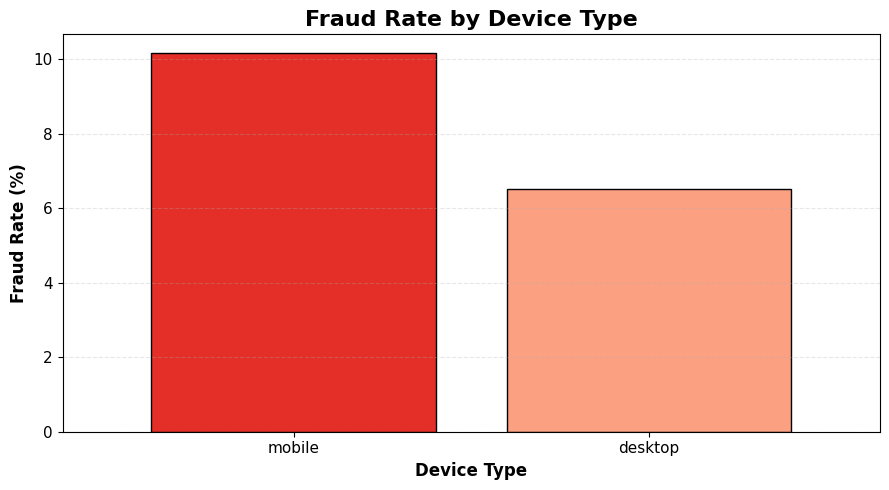

In [194]:
plt.figure(figsize=(9,5))

device_fraud.plot(kind="bar", color=sns.color_palette("Reds_r", len(device_fraud)), edgecolor="black", width=0.8)

plt.title("Fraud Rate by Device Type", fontsize=16, fontweight="bold")

plt.xlabel("Device Type", fontsize=12, fontweight="bold")

plt.ylabel("Fraud Rate (%)", fontsize=12, fontweight="bold")

plt.xticks(rotation=0, fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [195]:
# DeviceInfo Cleaning

def clean_device_info(device):
    device = str(device).lower()
    
    if "samsung" in device or "sm-" in device:
        return "Samsung"
    elif "iphone" in device or "ios" in device:
        return "iPhone"
    elif "windows" in device:
        return "Windows"
    elif "mac" in device:
        return "Mac"
    elif "android" in device:
        return "Android"
    elif device == "nan":
        return "Unknown"
    else:
        return "Other"

train_df["DeviceInfo_clean"] = train_df["DeviceInfo"].apply(clean_device_info)

In [196]:
train_df[["DeviceInfo","DeviceInfo_clean"]].head(20)

,DeviceInfo,DeviceInfo_clean
0,NaN,Unknown
1,NaN,Unknown
2,NaN,Unknown
3,NaN,Unknown
4,SAMSUNG SM-G892A Build/NRD90M,Samsung
5,NaN,Unknown
6,NaN,Unknown
7,NaN,Unknown
8,iOS Device,iPhone
9,NaN,Unknown


In [197]:
device_clean_fraud = train_df.groupby("DeviceInfo_clean")["isFraud"].mean().sort_values(ascending=False) * 100
device_clean_fraud

DeviceInfo_clean
Samsung    11.541039
Other       9.715988
Windows     6.553637
iPhone      6.273063
Android     3.658537
Unknown     2.554919
Mac         2.211087
Name: isFraud, dtype: float64

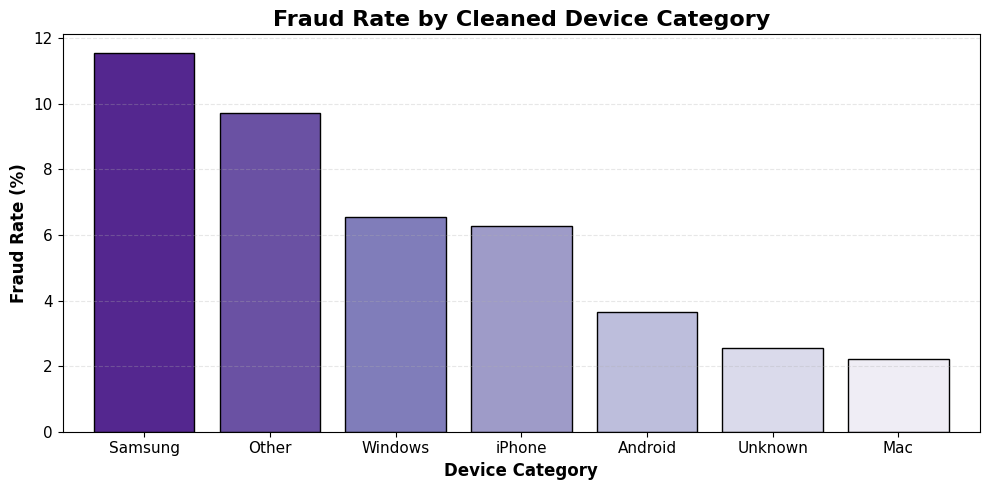

In [198]:
plt.figure(figsize=(10,5))

device_clean_fraud.plot(kind="bar", color=sns.color_palette("Purples_r", len(device_clean_fraud)), edgecolor="black", 
                        width=0.8)

plt.title("Fraud Rate by Cleaned Device Category", fontsize=16, fontweight="bold")

plt.xlabel("Device Category", fontsize=12, fontweight="bold")

plt.ylabel("Fraud Rate (%)", fontsize=12, fontweight="bold")

plt.xticks(rotation=0, fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [199]:
# Identity Missing Pattern

identity_cols = [col for col in train_df.columns if col.startswith("id_")]

train_df["identity_missing_count"] = train_df[identity_cols].isnull().sum(axis=1)
test_df["identity_missing_count"] = test_df[identity_cols].isnull().sum(axis=1)

train_df.groupby("isFraud")["identity_missing_count"].mean()

isFraud
0    32.489351
1    25.158447
Name: identity_missing_count, dtype: float64

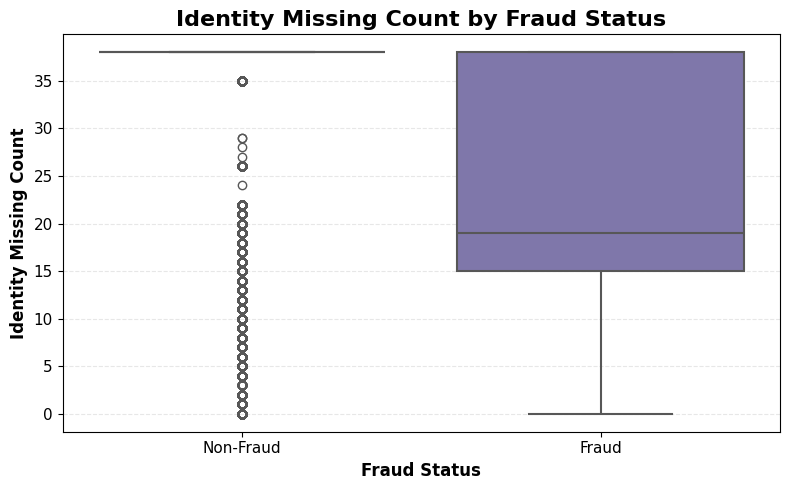

In [200]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train_df, x="isFraud", y="identity_missing_count", palette=sns.color_palette("Purples", 2), linewidth=1.5)

plt.title("Identity Missing Count by Fraud Status", fontsize=16, fontweight="bold")

plt.xlabel("Fraud Status", fontsize=12, fontweight="bold")

plt.ylabel("Identity Missing Count", fontsize=12, fontweight="bold")

plt.xticks([0,1], ["Non-Fraud", "Fraud"], fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

<p><i>Fraud transactions showed significantly higher identity missing counts compared to non-fraud transactions, indicating that incomplete identity information may be an important fraud detection signal</p></i>

In [201]:
# C, D, M, V Feature Group Analysis

c_cols = [col for col in train_df.columns if col.startswith("C")]
d_cols = [col for col in train_df.columns if col.startswith("D")]
m_cols = [col for col in train_df.columns if col.startswith("M")]
v_cols = [col for col in train_df.columns if col.startswith("V")]

print("C Columns:", len(c_cols))
print("D Columns:", len(d_cols))
print("M Columns:", len(m_cols))
print("V Columns:", len(v_cols))

C Columns: 14
D Columns: 18
M Columns: 9
V Columns: 339


In [202]:
selected_cols = c_cols + d_cols + v_cols + ["isFraud"]
numeric_data = train_df[selected_cols].select_dtypes(include=["number"])
numeric_corr = (numeric_data.corr()["isFraud"].abs().sort_values(ascending=False))
numeric_corr.head(30)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
V157       0.234866
V155       0.234199
V230       0.231740
V199       0.231024
V148       0.228891
V51        0.223191
V171       0.216508
V40        0.212442
V243       0.210238
Name: isFraud, dtype: float64

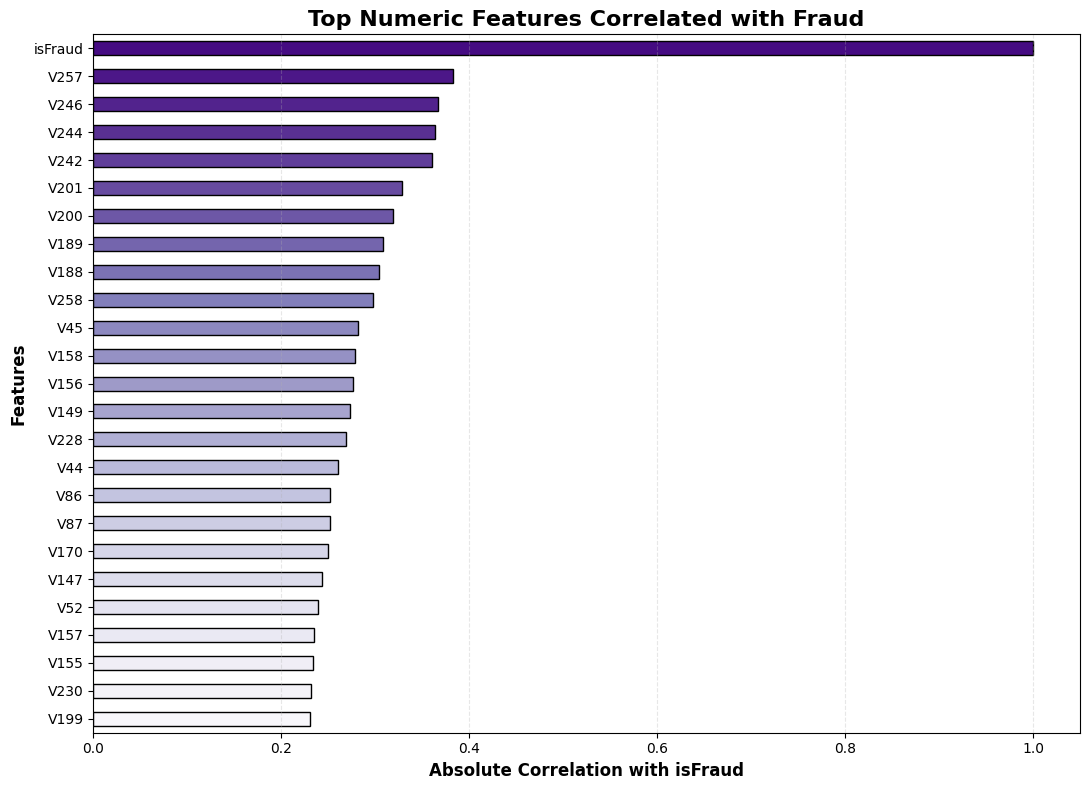

In [203]:
plt.figure(figsize=(11,8))

numeric_corr.head(25).sort_values().plot(kind="barh", color=sns.color_palette("Purples", 25), edgecolor="black")

plt.title("Top Numeric Features Correlated with Fraud", fontsize=16, fontweight="bold")

plt.xlabel("Absolute Correlation with isFraud", fontsize=12, fontweight="bold")

plt.ylabel("Features", fontsize=12, fontweight="bold")

plt.xticks(fontsize=10)

plt.yticks(fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [205]:
# Total Missing Count Feature

train_df["total_missing_count"] = train_df.isnull().sum(axis=1)

In [206]:
train_df[["total_missing_count"]].head(10)

,total_missing_count
0,237
1,231
2,212
3,228
4,138
5,215
6,212
7,231
8,135
9,212


In [207]:
# Risk Encoding Features

risk_cols = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo_clean"]

for col in risk_cols:
    risk_map = train_df.groupby(col)["isFraud"].mean()
    train_df[f"{col}_risk"] = train_df[col].map(risk_map)

In [208]:
risk_feature_cols = [f"{col}_risk" for col in risk_cols]
train_df["custom_risk_score"] = train_df[risk_feature_cols].mean(axis=1)

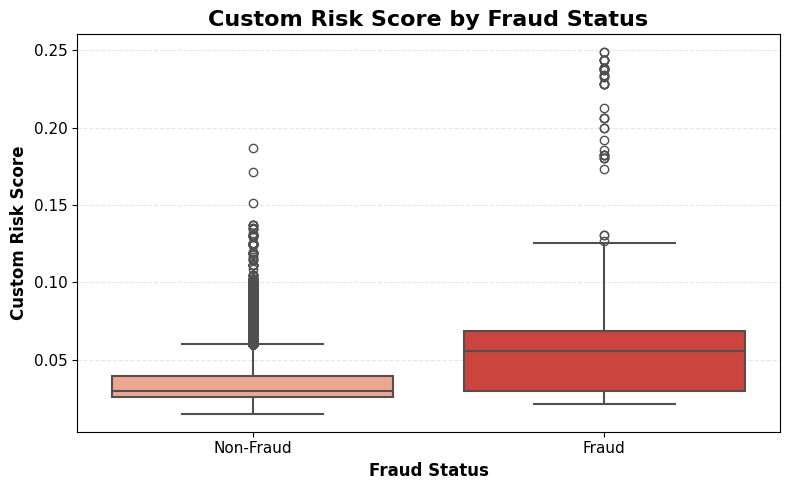

In [209]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train_df, x="isFraud", y="custom_risk_score", palette=sns.color_palette("Reds", 2), linewidth=1.5)

plt.title("Custom Risk Score by Fraud Status", fontsize=16, fontweight="bold")

plt.xlabel("Fraud Status", fontsize=12, fontweight="bold")

plt.ylabel("Custom Risk Score", fontsize=12, fontweight="bold")

plt.xticks([0,1], ["Non-Fraud", "Fraud"], fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [211]:
# Data Cleaning for Modeling

drop_cols = ["TransactionID", "card_combo", "amount_bucket"]
target = "isFraud"
X = train_df.drop(columns=[target] + drop_cols, errors="ignore")
y = train_df[target]

In [212]:
X.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,identity_missing_count,total_missing_count,ProductCD_risk,card4_risk,card6_risk,P_emaildomain_risk,R_emaildomain_risk,DeviceType_risk,DeviceInfo_clean_risk,custom_risk_score
0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,...,38,237,0.020399,0.077282,0.066785,NaN,NaN,NaN,0.025549,0.047504
1,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,...,38,231,0.020399,0.034331,0.066785,0.043542,NaN,NaN,0.025549,0.038121
2,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,...,38,212,0.020399,0.034756,0.024263,0.094584,NaN,NaN,0.025549,0.039910
3,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,...,38,228,0.020399,0.034331,0.024263,0.022757,NaN,NaN,0.025549,0.025460
4,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,...,17,138,0.047662,0.034331,0.066785,0.043542,NaN,0.101662,0.115410,0.068232


In [213]:
#Remove Very High Missing Columns

missing_percent = X.isnull().mean() * 100
high_missing_cols = missing_percent[missing_percent > 90].index.tolist()
print("High Missing Columns:", len(high_missing_cols))
X = X.drop(columns=high_missing_cols, errors="ignore")

High Missing Columns: 12


In [214]:
common_cols = X.columns.intersection(test_model_df.columns)
X = X[common_cols]
test_model_df = test_model_df[common_cols]
print("Final Training Features:", X.shape)
print("Final Test Features:", test_model_df.shape)

Final Training Features: (590540, 450)
Final Test Features: (506691, 450)


In [215]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns

print("Numeric Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numeric Columns: 420
Categorical Columns: 30


In [216]:
for col in num_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
for col in cat_cols:
    X[col] = X[col].fillna("Unknown")   

In [217]:
# Categorical Encoding

for col in cat_cols:
    le = LabelEncoder()   
    combined_values = pd.concat([
        X[col].astype(str),
    ], axis=0)   
    le.fit(combined_values)  
    X[col] = le.transform(X[col].astype(str))

In [218]:
# Final Null Check

print("Train Missing Values:", X.isnull().sum().sum())

Train Missing Values: 0


In [219]:
# Train Validation Split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train fraud rate:", y_train.mean() * 100)
print("y_valid fraud rate:", y_valid.mean() * 100)

X_train: (472432, 450)
X_valid: (118108, 450)
y_train fraud rate: 3.498916246147594
y_valid fraud rate: 3.49933958749619


In [220]:
# Evaluation Function

def evaluate_model(model, X_valid, y_valid, model_name):
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:, 1]
    
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    auc = roc_auc_score(y_valid, y_proba)
    
    print(f"Model: {model_name}")
    print("-" * 40)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(auc, 4))
    print("\nClassification Report:")
    print(classification_report(y_valid, y_pred))
    
    return {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": auc
    }

In [221]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

log_model.fit(X_train, y_train)

log_results = evaluate_model(
    log_model,
    X_valid,
    y_valid,
    "Logistic Regression"
)

Model: Logistic Regression
----------------------------------------
Precision: 0.103
Recall: 0.5684
F1 Score: 0.1744
ROC-AUC: 0.7328

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89    113975
           1       0.10      0.57      0.17      4133

    accuracy                           0.81    118108
   macro avg       0.54      0.69      0.53    118108
weighted avg       0.95      0.81      0.87    118108



In [222]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_valid,
    y_valid,
    "Random Forest"
)

Model: Random Forest
----------------------------------------
Precision: 0.2312
Recall: 0.7433
F1 Score: 0.3527
ROC-AUC: 0.9066

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    113975
           1       0.23      0.74      0.35      4133

    accuracy                           0.90    118108
   macro avg       0.61      0.83      0.65    118108
weighted avg       0.96      0.90      0.93    118108



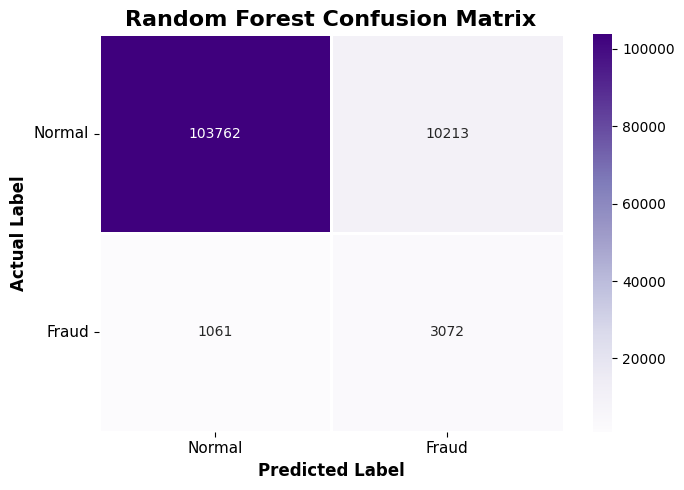

In [223]:
# Confusion Matrix

y_pred_rf = rf_model.predict(X_valid)

cm = confusion_matrix(y_valid, y_pred_rf)

plt.figure(figsize=(7,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"],
    linewidths=1,linecolor="white")

plt.title("Random Forest Confusion Matrix", fontsize=16, fontweight="bold")

plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")

plt.ylabel("Actual Label", fontsize=12, fontweight="bold")

plt.xticks(fontsize=11)

plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()

plt.show()

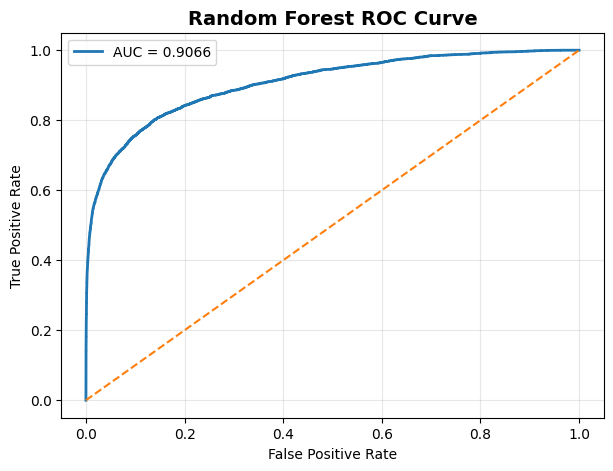

In [224]:
# ROC Curve

y_proba_rf = rf_model.predict_proba(X_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, y_proba_rf)
auc_score = roc_auc_score(y_valid, y_proba_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Random Forest ROC Curve", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

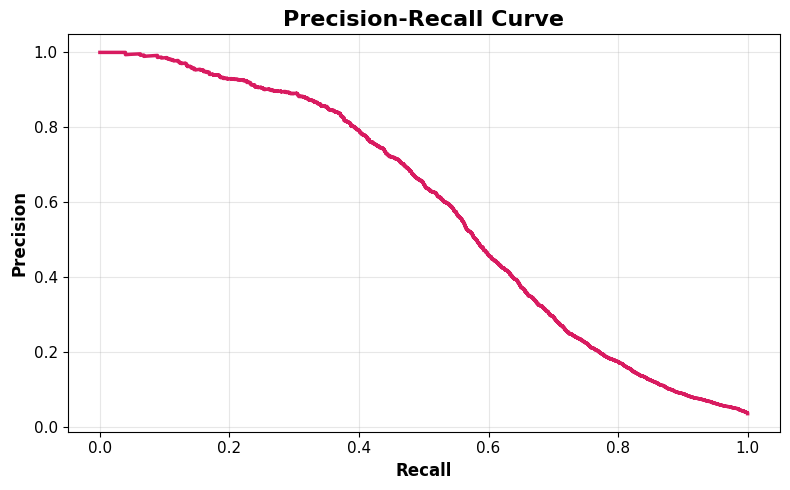

In [225]:
# Precision-Recall Curve

precision, recall, pr_thresholds = precision_recall_curve(y_valid, y_proba_rf)

plt.figure(figsize=(8,5))

plt.plot(recall, precision, color="#D81B60", linewidth=2.5)

plt.title("Precision-Recall Curve", fontsize=16, fontweight="bold")

plt.xlabel("Recall", fontsize=12, fontweight="bold")

plt.ylabel("Precision", fontsize=12, fontweight="bold")

plt.xticks(fontsize=11)

plt.yticks(fontsize=11)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [226]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
449,custom_risk_score,0.031878
26,C13,0.027323
27,C14,0.023076
120,V70,0.021699
140,V90,0.018125
13,R_emaildomain,0.016790
268,V218,0.016592
308,V258,0.016518
368,V318,0.016414
251,V201,0.015780


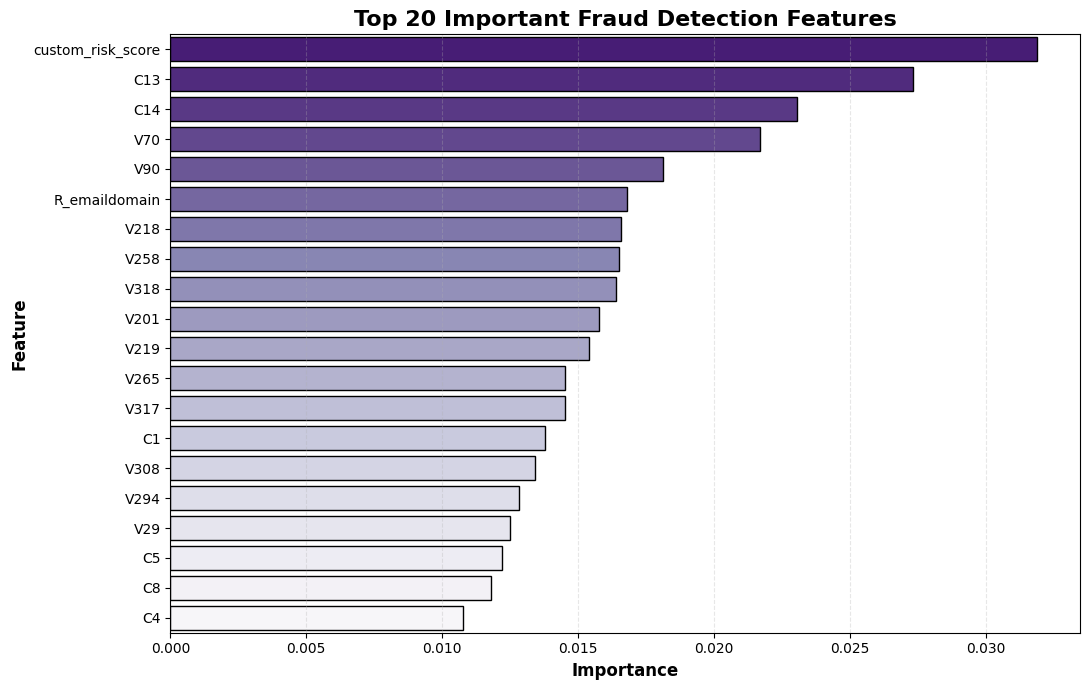

In [227]:
plt.figure(figsize=(11,7))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature",
    palette=sns.color_palette("Purples_r", 20),
    edgecolor="black"
)

plt.title("Top 20 Important Fraud Detection Features", fontsize=16, fontweight="bold")

plt.xlabel("Importance", fontsize=12, fontweight="bold")

plt.ylabel("Feature", fontsize=12, fontweight="bold")

plt.xticks(fontsize=10)

plt.yticks(fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [228]:
# Threshold Tuning

threshold_results = []

for threshold in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    custom_pred = (y_proba_rf >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, custom_pred),
        "Recall": recall_score(y_valid, custom_pred),
        "F1_Score": f1_score(y_valid, custom_pred)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1_Score
0,0.1,0.041227,0.994677,0.079173
1,0.2,0.054729,0.966610,0.103593
2,0.3,0.095644,0.886039,0.172650
3,0.4,0.148990,0.822889,0.252300
4,0.5,0.231238,0.743286,0.352739
5,0.6,0.376279,0.649407,0.476478
6,0.7,0.590129,0.541011,0.564504


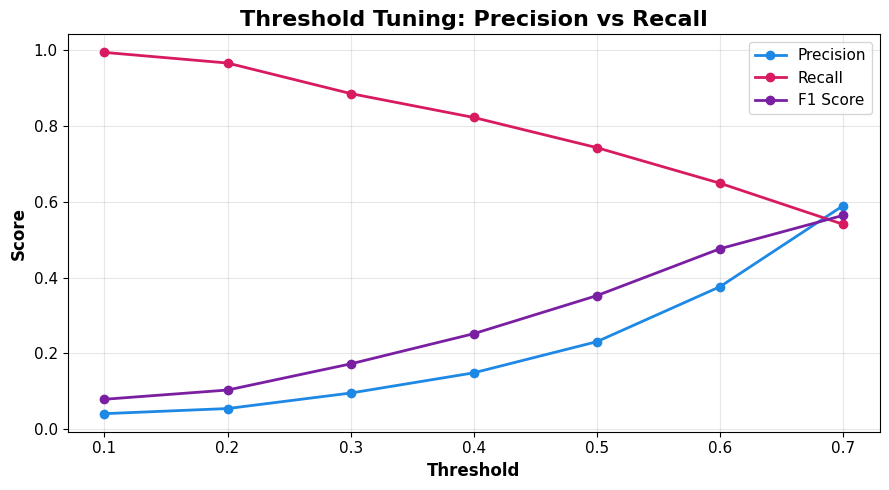

In [229]:
plt.figure(figsize=(9,5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", linewidth=2, color="#1E88E5", label="Precision")

plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", linewidth=2, color="#D81B60", label="Recall")

plt.plot(threshold_df["Threshold"], threshold_df["F1_Score"], marker="o", linewidth=2, color="#7B1FA2", label="F1 Score")

plt.title("Threshold Tuning: Precision vs Recall", fontsize=16, fontweight="bold")

plt.xlabel("Threshold", fontsize=12, fontweight="bold")

plt.ylabel("Score", fontsize=12, fontweight="bold")

plt.xticks(fontsize=11)

plt.yticks(fontsize=11)

plt.legend(fontsize=11)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [230]:
iso_model = IsolationForest(n_estimators=200,
    contamination=y_train.mean(),
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",np.float64(0....8916246147594)
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [231]:
anomaly_pred = iso_model.predict(X_valid)

anomaly_flag = np.where(anomaly_pred == -1, 1, 0)

anomaly_comparison = pd.crosstab(
    y_valid,
    anomaly_flag,
    rownames=["Actual Fraud"],
    colnames=["Anomaly Flag"]
)

anomaly_comparison

Anomaly Flag,0,1
Actual Fraud,,
0,110832,3143
1,3147,986


In [232]:
print("Isolation Forest Recall:", recall_score(y_valid, anomaly_flag))
print("Isolation Forest Precision:", precision_score(y_valid, anomaly_flag))

Isolation Forest Recall: 0.2385676264214856
Isolation Forest Precision: 0.23879874061516104


In [233]:
model_comparison = pd.DataFrame([log_results,rf_results])
model_comparison

,Model,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.103026,0.568352,0.174433,0.732825
1,Random Forest,0.231238,0.743286,0.352739,0.906563


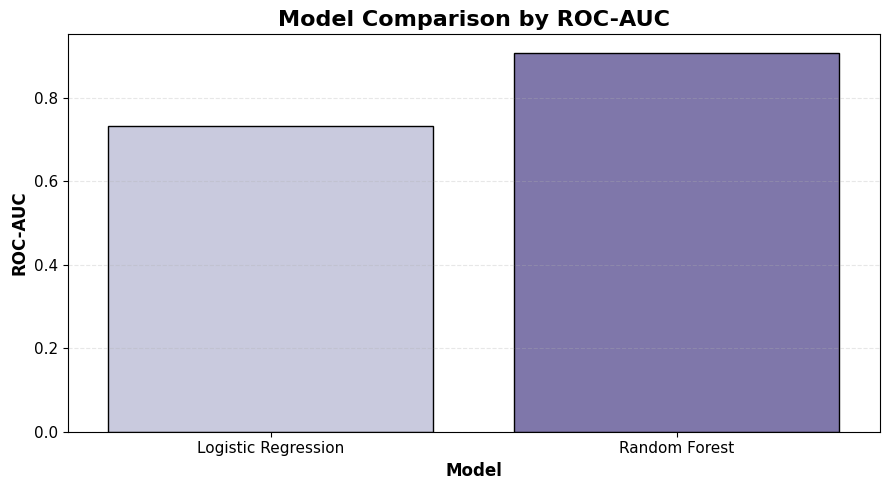

In [234]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="ROC_AUC",
    palette=sns.color_palette("Purples", len(model_comparison)),
    edgecolor="black"
)

plt.title("Model Comparison by ROC-AUC", fontsize=16, fontweight="bold")

plt.xlabel("Model", fontsize=12, fontweight="bold")

plt.ylabel("ROC-AUC", fontsize=12, fontweight="bold")

plt.xticks(fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [235]:
# Final Model Training

final_model = RandomForestClassifier(n_estimators=250,max_depth=14,min_samples_split=10,
    class_weight="balanced",random_state=42,n_jobs=-1)
final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [240]:
# Risk Segmentation

def risk_segment(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"
final_prediction["Risk_Level"] = final_prediction["Fraud_Probability"].apply(risk_segment)
final_prediction.head()

,TransactionID,Fraud_Probability,Risk_Level
0,3663549,0.119345,Low Risk
1,3663550,0.235462,Low Risk
2,3663551,0.282428,Low Risk
3,3663552,0.094500,Low Risk
4,3663553,0.087552,Low Risk


In [241]:
risk_distribution = final_prediction["Risk_Level"].value_counts()

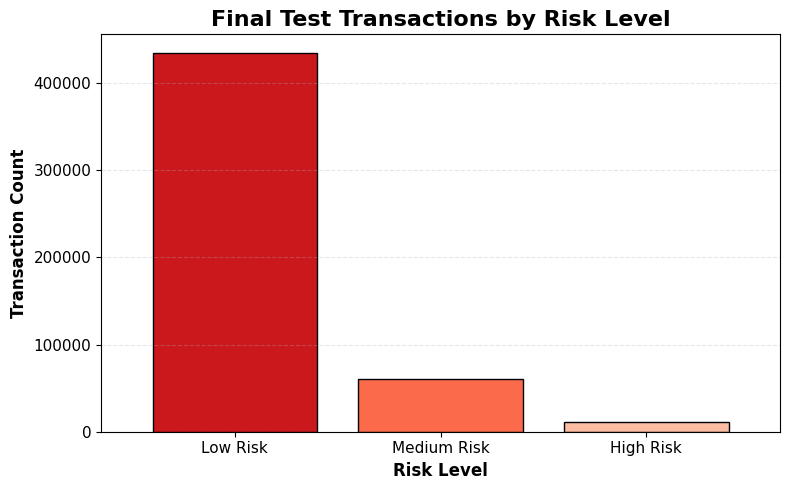

In [242]:
plt.figure(figsize=(8,5))

risk_distribution.plot(kind="bar", color=sns.color_palette("Reds_r", len(risk_distribution)), edgecolor="black", width=0.8)

plt.title("Final Test Transactions by Risk Level", fontsize=16, fontweight="bold")

plt.xlabel("Risk Level", fontsize=12, fontweight="bold")

plt.ylabel("Transaction Count", fontsize=12, fontweight="bold")

plt.xticks(rotation=0, fontsize=11)

plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [243]:
#Save Risk Intelligence Output

final_prediction.to_csv("fraud_risk_intelligence_output.csv", index=False)

In [244]:
# Final cleaned fraud dataset save
train_df.to_csv(
    "cleaned_fraud_transaction_dataset.csv",
    index=False
)

<h1 style="color:#D85A30 ; font-family:Georgia"> <b>
Business Insights</b>
</h1>

1. Fraud transactions are very low compared to normal transactions. The dataset is highly imbalanced with only **3.50%** fraud transactions.

2. Most transactions are small or medium value transactions, while a few transactions contain very large amounts.

3. Fraud rate changes across different transaction amount groups. Both very low and very high amount transactions showed higher fraud activity.

4. Fraud behavior changes across different transaction hours, showing that **transaction timing** is an important fraud signal.

5. Product categories showed different fraud patterns. **ProductCD = C** had much higher fraud rate compared to other product groups.

6. Card-related features were useful for fraud detection. **Discover cards** and **credit cards** showed higher fraud risk.

7. Email domain behavior became an important fraud indicator. Some purchaser and receiver email domains showed very high fraud rates.

8. Transactions with **matching purchaser and receiver email domains** showed higher fraud probability.

9. Missing distance information itself became a useful fraud signal because transactions with missing distance values showed higher fraud rate.

10. **Mobile devices** showed higher fraud activity compared to desktop devices.

11. Cleaning and grouping **DeviceInfo** improved fraud pattern understanding and helped identify risky device categories.

12. The **custom risk score** became one of the most important features for fraud prediction.

13. **Random Forest** performed much better than Logistic Regression in fraud detection performance.

14. **Recall** became the most important metric because missing fraud transactions can create direct financial loss.

15. **Threshold tuning** helped balance fraud detection and false alerts based on business requirements.

16. **Isolation Forest** added extra support by detecting unusual transaction behavior without directly using fraud labels.

<h1 style="color:#D85A30 ; font-family:Georgia"> <b>
Conclusion</b>
</h1>


This project built a complete fraud detection system using transaction and identity data.

The dataset was highly imbalanced, with only **3.50% fraud transactions**, so precision, recall, F1-score, and ROC-AUC were used instead of depending only on accuracy.

After EDA, feature engineering, risk scoring, and model comparison, **Random Forest** performed better than Logistic Regression with **0.9066 ROC-AUC** and **74.33% recall**.

The final model predicted fraud probability for unseen transactions and divided them into **Low Risk, Medium Risk, and High Risk** groups.

This project shows how machine learning can help financial companies detect suspicious transactions and reduce fraud risk.